In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

In [2]:
with open('all_df_properties.json') as f:
    dataset_properties = json.load(f)  # Assume multiple datasets are in this format

properties = []
for data in dataset_properties:
    name = data['name']
    dataset = data['dataset']
    multi_di_graph = data['multi_di_graph']

    properties.append({
        'Dataset': name,
        'Multi-class Gini': dataset['Multi-class Gini Coefficient'],
        # 'Binary Gini': dataset['Binary Classification Gini Coefficient'],
        # 'Percentage Benign': dataset['percentage_of_benign_records'],
        # 'Percentage Attack': dataset['percentage_of_attack_records'],
        # 'number_of_nodes': multi_di_graph['graph_measures']['number_of_nodes'],
        # 'number_of_edges': multi_di_graph['graph_measures']['number_of_edges'],
        # 'max_degree': multi_di_graph['graph_measures']['max_degree'],
        'avg_degree': multi_di_graph['graph_measures']['avg_degree'],
        'density': multi_di_graph['graph_measures']['density'],
        # 'degree_skewness': multi_di_graph['degree_skewness'],
        # 'degree_kurtosis': multi_di_graph['degree_kurtosis'],
        'degree_alpha': multi_di_graph['degree_alpha'],
        # 'degree_entropy': multi_di_graph['degree_entropy'],
        'degree_relative_entropy': multi_di_graph['degree_relative_entropy'],
        'degree_scale_free': multi_di_graph['degree_scale_free'],
        # 'pagerank_skewness': multi_di_graph['pagerank_skewness'],
        # 'pagerank_entropy': multi_di_graph['pagerank_entropy'],
        'pagerank_relative_entropy': multi_di_graph['pagerank_relative_entropy'],
        'pagerank_alpha': multi_di_graph['pagerank_alpha'],
        'pagerank_scale_free': multi_di_graph['pagerank_scale_free'],
        # 'betweenness_skewness': multi_di_graph['betweenness_skewness'],
        # 'betweenness_entropy': multi_di_graph['betweenness_entropy'],
        'betweenness_relative_entropy': multi_di_graph['betweenness_relative_entropy'],
        'betweenness_alpha': multi_di_graph['betweenness_alpha'],
        'betweenness_scale_free': multi_di_graph['betweenness_scale_free'],
        # 'k_truss_skewness': multi_di_graph['k_truss_skewness'],
        # 'k_truss_entropy': multi_di_graph['k_truss_entropy'],
        'k_truss_relative_entropy': multi_di_graph['k_truss_relative_entropy'],
        'k_truss_alpha': multi_di_graph['k_truss_alpha'],
        # 'k_truss_scale_free': multi_di_graph['k_truss_scale_free'],
        # 'intersection between attacks and victims': multi_di_graph['intersection between attacks and victims'],
        'Proportion of Attackers': multi_di_graph['Proportion of Attackers'],
        # 'Proportion of Victims': multi_di_graph['Proportion of Victims'],
        # 'Mean Clustering Coefficient': multi_di_graph['Mean Clustering Coefficient'],
        # 'Degree Assortativity': multi_di_graph['Graph Degree Assortativity Coefficient'],
        # 'Mean Path Length': multi_di_graph['Mean Path Length'],
        'class_diversity_entropy': multi_di_graph['class_diversity_entropy'],
        'class_diversity_ratio': multi_di_graph['class_diversity_ratio'],
    })
# properties

In [3]:
properties_df = pd.DataFrame(properties)
properties_df

,Dataset,Multi-class Gini,avg_degree,density,degree_alpha,degree_relative_entropy,degree_scale_free,pagerank_relative_entropy,pagerank_alpha,pagerank_scale_free,betweenness_relative_entropy,betweenness_alpha,betweenness_scale_free,k_truss_relative_entropy,k_truss_alpha,Proportion of Attackers,class_diversity_entropy,class_diversity_ratio
0,cic_ton_iot,0.751213,75.006946,0.000263,1.539547,0.174882,0,0.010834,1.407399,0,0.001455,1.262840,0,0.101750,48.424412,0.000077,0.0001,0.5253
1,cic_ids_2017,0.878124,294.304773,0.007693,2.046122,0.440548,1,0.830852,2.193557,1,0.559536,1.493652,0,0.172750,3.204116,0.000523,0.0001,0.3379
2,cic_bot_iot,0.436253,91343.659864,155.876553,1.654160,0.503829,0,0.532433,3.470760,0,0.047849,2.175956,1,0.029794,45.847600,0.027211,0.0329,0.5178
3,cic_ton_iot_modified,0.635358,149.980623,0.001144,5.279120,0.176466,0,0.019362,1.375214,0,0.001998,1.639140,0,0.104800,38.509320,0.000122,0.0001,0.4130
4,ccd_inid_modified,0.419770,1246.582524,6.110699,1.337243,0.814577,0,0.703732,1.687602,0,0.186107,1.408055,0,0.053581,37.289894,0.475728,0.2622,0.4196
5,nf_uq_nids_modified,0.835980,27033.325153,83.436189,1.249088,0.687675,0,0.733947,5.033510,0,0.301091,1.913212,0,0.056646,19.798043,0.073620,0.1259,0.0525
6,edge_iiot,0.761388,22.999191,0.000065,114.007111,0.021798,0,0.063423,227.410485,0,0.000012,1.188348,0,0.020002,58192.373208,0.776236,0.0001,0.9998
7,nf_cse_cic_ids2018,0.904128,158.853789,0.000862,1.780424,0.239182,0,0.259530,1.915698,0,0.064030,1.239415,0,0.005790,174.154738,0.007862,0.0022,0.6175
8,nf_uq_nids,0.884595,229.142805,0.001223,1.770360,0.240163,0,0.268201,1.913730,0,0.064319,1.236619,0,0.006367,155.511399,0.007998,0.0025,0.6170
9,x_iiot,0.683325,11282.392857,50.821589,1.263443,0.829736,0,0.814292,2.212470,1,0.107337,2.012183,1,0.161024,9.615089,0.080357,0.0387,0.2089


In [4]:
for feature in properties_df.columns:
    if feature != "Dataset":
        print(f"==>> feature: {feature}")
        # Sort the DataFrame by the current feature in ascending order and print the "Dataset" column along with the current feature.
        sorted_df = properties_df.sort_values(by=feature, ascending=True)
        print(sorted_df[["Dataset", feature]])


==>> feature: Multi-class Gini
                Dataset  Multi-class Gini
4     ccd_inid_modified          0.419770
2           cic_bot_iot          0.436253
3  cic_ton_iot_modified          0.635358
9                x_iiot          0.683325
0           cic_ton_iot          0.751213
6             edge_iiot          0.761388
5   nf_uq_nids_modified          0.835980
1          cic_ids_2017          0.878124
8            nf_uq_nids          0.884595
7    nf_cse_cic_ids2018          0.904128
==>> feature: avg_degree
                Dataset    avg_degree
6             edge_iiot     22.999191
0           cic_ton_iot     75.006946
3  cic_ton_iot_modified    149.980623
7    nf_cse_cic_ids2018    158.853789
8            nf_uq_nids    229.142805
1          cic_ids_2017    294.304773
4     ccd_inid_modified   1246.582524
9                x_iiot  11282.392857
5   nf_uq_nids_modified  27033.325153
2           cic_bot_iot  91343.659864
==>> feature: density
                Dataset     density
6     

In [5]:
# models = ['e_gcn', 'e_graph_sage', 'e_gat']
# models = ['e_gcn', 'e_gat']
# models = ['e_gcn', 'e_graph_sage']
models = ['e_graph_sage', 'e_gat']
f1_scores = pd.read_csv('f1_scores.csv', usecols=['Dataset'] + models)
f1_scores

,Dataset,e_graph_sage,e_gat
0,cic_ids_2017,98.403,98.170
1,cic_ton_iot_modified,84.400,83.780
2,ccd_inid_modified,93.660,78.660
3,x_iiot,93.410,94.527
4,edge_iiot,96.980,95.210
5,cic_ton_iot,82.850,84.660
6,nf_uq_nids,84.270,81.830
7,nf_cse_cic_ids2018,93.950,94.024
8,nf_uq_nids_modified,90.980,88.270


In [6]:
f1_scores['Dataset'] = f1_scores['Dataset'].str.strip().str.lower()
properties_df['Dataset'] = properties_df['Dataset'].str.strip().str.lower()

merged_df = pd.merge(properties_df, f1_scores, on='Dataset')
merged_df

,Dataset,Multi-class Gini,avg_degree,density,degree_alpha,degree_relative_entropy,degree_scale_free,pagerank_relative_entropy,pagerank_alpha,pagerank_scale_free,betweenness_relative_entropy,betweenness_alpha,betweenness_scale_free,k_truss_relative_entropy,k_truss_alpha,Proportion of Attackers,class_diversity_entropy,class_diversity_ratio,e_graph_sage,e_gat
0,cic_ton_iot,0.751213,75.006946,0.000263,1.539547,0.174882,0,0.010834,1.407399,0,0.001455,1.262840,0,0.101750,48.424412,0.000077,0.0001,0.5253,82.850,84.660
1,cic_ids_2017,0.878124,294.304773,0.007693,2.046122,0.440548,1,0.830852,2.193557,1,0.559536,1.493652,0,0.172750,3.204116,0.000523,0.0001,0.3379,98.403,98.170
2,cic_ton_iot_modified,0.635358,149.980623,0.001144,5.279120,0.176466,0,0.019362,1.375214,0,0.001998,1.639140,0,0.104800,38.509320,0.000122,0.0001,0.4130,84.400,83.780
3,ccd_inid_modified,0.419770,1246.582524,6.110699,1.337243,0.814577,0,0.703732,1.687602,0,0.186107,1.408055,0,0.053581,37.289894,0.475728,0.2622,0.4196,93.660,78.660
4,nf_uq_nids_modified,0.835980,27033.325153,83.436189,1.249088,0.687675,0,0.733947,5.033510,0,0.301091,1.913212,0,0.056646,19.798043,0.073620,0.1259,0.0525,90.980,88.270
5,edge_iiot,0.761388,22.999191,0.000065,114.007111,0.021798,0,0.063423,227.410485,0,0.000012,1.188348,0,0.020002,58192.373208,0.776236,0.0001,0.9998,96.980,95.210
6,nf_cse_cic_ids2018,0.904128,158.853789,0.000862,1.780424,0.239182,0,0.259530,1.915698,0,0.064030,1.239415,0,0.005790,174.154738,0.007862,0.0022,0.6175,93.950,94.024
7,nf_uq_nids,0.884595,229.142805,0.001223,1.770360,0.240163,0,0.268201,1.913730,0,0.064319,1.236619,0,0.006367,155.511399,0.007998,0.0025,0.6170,84.270,81.830
8,x_iiot,0.683325,11282.392857,50.821589,1.263443,0.829736,0,0.814292,2.212470,1,0.107337,2.012183,1,0.161024,9.615089,0.080357,0.0387,0.2089,93.410,94.527


In [7]:
merged_df.columns

Index(['Dataset', 'Multi-class Gini', 'avg_degree', 'density', 'degree_alpha',
       'degree_relative_entropy', 'degree_scale_free',
       'pagerank_relative_entropy', 'pagerank_alpha', 'pagerank_scale_free',
       'betweenness_relative_entropy', 'betweenness_alpha',
       'betweenness_scale_free', 'k_truss_relative_entropy', 'k_truss_alpha',
       'Proportion of Attackers', 'class_diversity_entropy',
       'class_diversity_ratio', 'e_graph_sage', 'e_gat'],
      dtype='object')

## Random Forest

In [8]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# merged_df['best_model'] = merged_df[models].idxmax(axis=1)

# # Convert categorical target to numerical labels
# merged_df['best_model'] = merged_df['best_model'].astype('category').cat.codes  # 0, 1, 2 for models

# # Separate features and target
# X = merged_df.drop(columns=models + ["Dataset", 'best_model'])  # Use only feature columns
# y = merged_df['best_model']

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train a classifier
# clf = RandomForestClassifier(n_estimators=100, random_state=42)
# clf.fit(X_train, y_train)

# # Predictions
# y_pred = clf.predict(X_test)

# # Display classification report
# print(classification_report(y_test, y_pred, target_names=models))

# # Show feature importances
# feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})
# feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

To check for each model alone

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

def compute_feature_importance(merged_df, models, target_model):
    """
    Trains a Random Forest classifier on the full dataset to compute feature importance 
    for predicting when the given target model performs best.

    Args:
        merged_df (pd.DataFrame): The DataFrame containing model scores and features.
        models (list): List of model names in the DataFrame.
        target_model (str): The model for which feature importance is computed.

    Returns:
        pd.DataFrame: A DataFrame containing feature importance scores.
    """
    print(f"\n{'='*30}\nComputing feature importance for: {target_model}\n{'='*30}")

    # Define features (exclude model scores, dataset column, and other binary target columns)
    exclude_columns = models + ["Dataset"] + [f"{m}_better" for m in models]
    X = merged_df.drop(columns=exclude_columns)
    y = merged_df[f'{target_model}_better']

    # Train Random Forest Classifier on the full dataset (no train-test split)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X, y)

    # Compute feature importances
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': clf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print(feature_importance)
    return feature_importance


In [10]:
feature_importance_results = {}

for model in models:
    merged_df[f'{model}_better'] = (merged_df[models].idxmax(axis=1) == model).astype(int)

for model in models:
    feature_importance_results[model] = compute_feature_importance(merged_df, models, model)



Computing feature importance for: e_graph_sage
                         Feature  Importance
12      k_truss_relative_entropy    0.169513
10             betweenness_alpha    0.101794
2                        density    0.084899
0               Multi-class Gini    0.079081
6      pagerank_relative_entropy    0.073877
3                   degree_alpha    0.065102
13                 k_truss_alpha    0.062389
9   betweenness_relative_entropy    0.061776
11        betweenness_scale_free    0.054308
7                 pagerank_alpha    0.052869
4        degree_relative_entropy    0.052595
14       Proportion of Attackers    0.048239
1                     avg_degree    0.043759
16         class_diversity_ratio    0.025241
15       class_diversity_entropy    0.021981
8            pagerank_scale_free    0.002577
5              degree_scale_free    0.000000

Computing feature importance for: e_gat
                         Feature  Importance
12      k_truss_relative_entropy    0.169513
10         

## Correlation Matrix

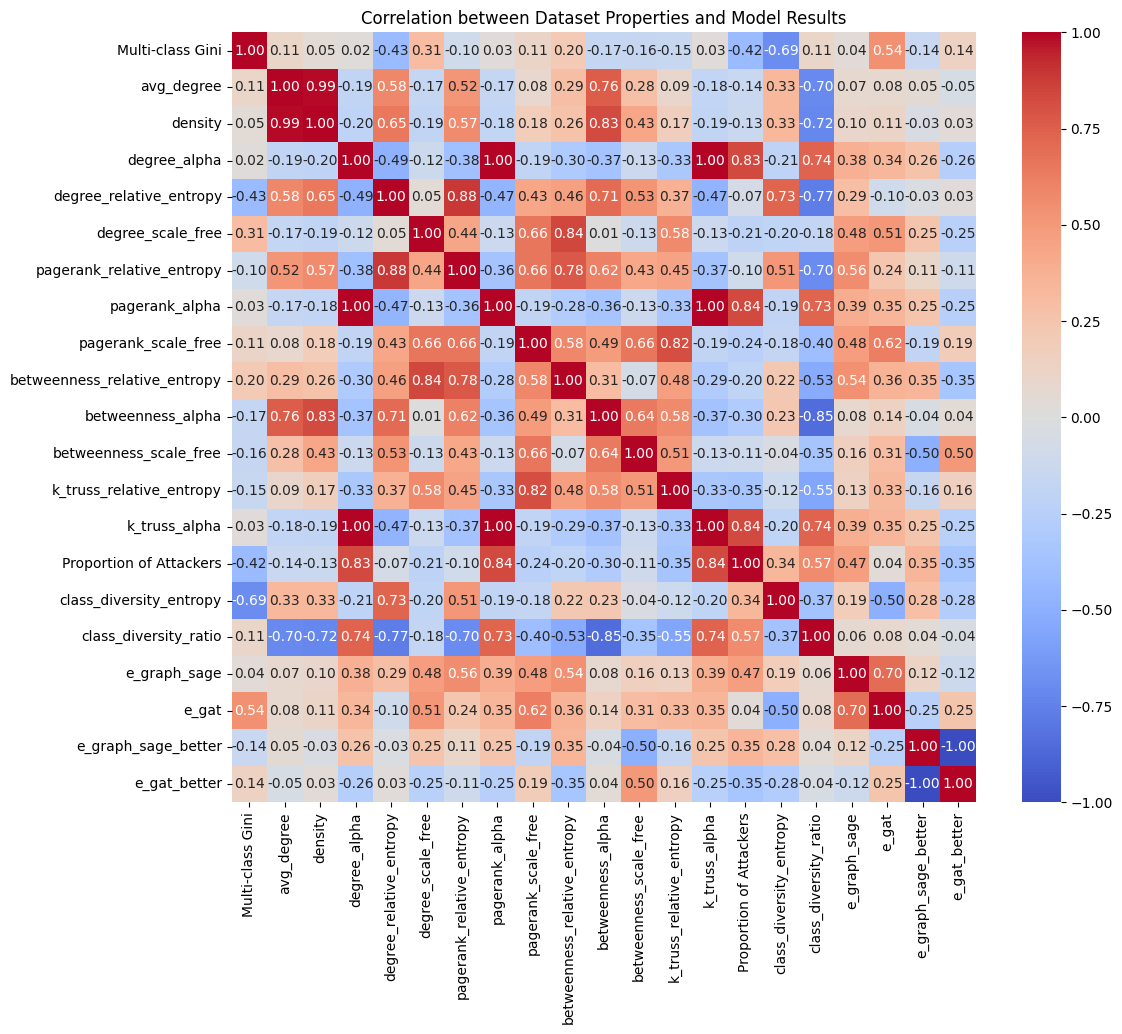

In [11]:
# Remove non-numeric columns for correlation calculation
numeric_columns = merged_df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = merged_df[numeric_columns].corr()

# Step 5: Visualize correlations using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Dataset Properties and Model Results')
plt.show()

# Datasets Clustering

In [12]:
feature_columns = list(properties_df.columns.drop("Dataset"))


Datasets grouped into clusters:
                Dataset  Cluster
0           cic_ton_iot        0
1          cic_ids_2017        0
2  cic_ton_iot_modified        0
3     ccd_inid_modified        0
4   nf_uq_nids_modified        2
5             edge_iiot        1
6    nf_cse_cic_ids2018        0
7            nf_uq_nids        0
8                x_iiot        0


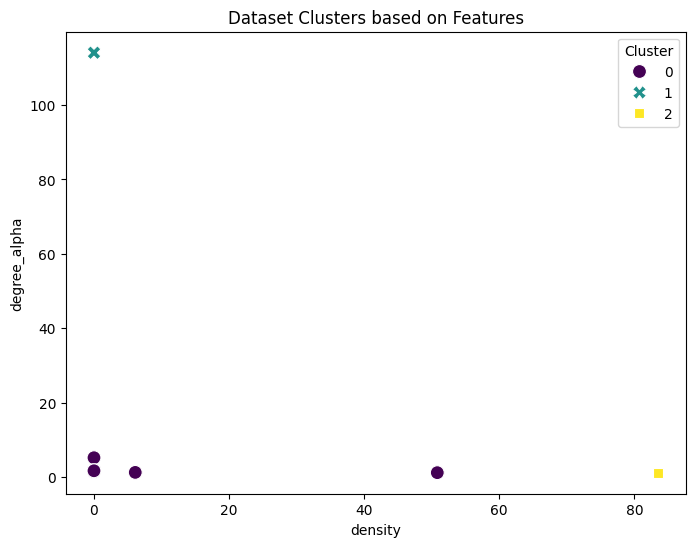

In [13]:

from sklearn.cluster import KMeans
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
features = merged_df[feature_columns]
merged_df['Cluster'] = kmeans.fit_predict(features)

# Display datasets with their assigned clusters
print("\nDatasets grouped into clusters:")
print(merged_df[['Dataset', 'Cluster']])

# Step 6: Visualize the clusters (optional)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='density', 
    y='degree_alpha', 
    hue='Cluster', 
    data=merged_df, 
    palette='viridis', 
    style='Cluster', 
    s=100
)
plt.title('Dataset Clusters based on Features')
plt.xlabel('density')
plt.ylabel('degree_alpha')
plt.legend(title='Cluster')
plt.show()

merged_df = merged_df.drop(["Cluster"], axis=1)

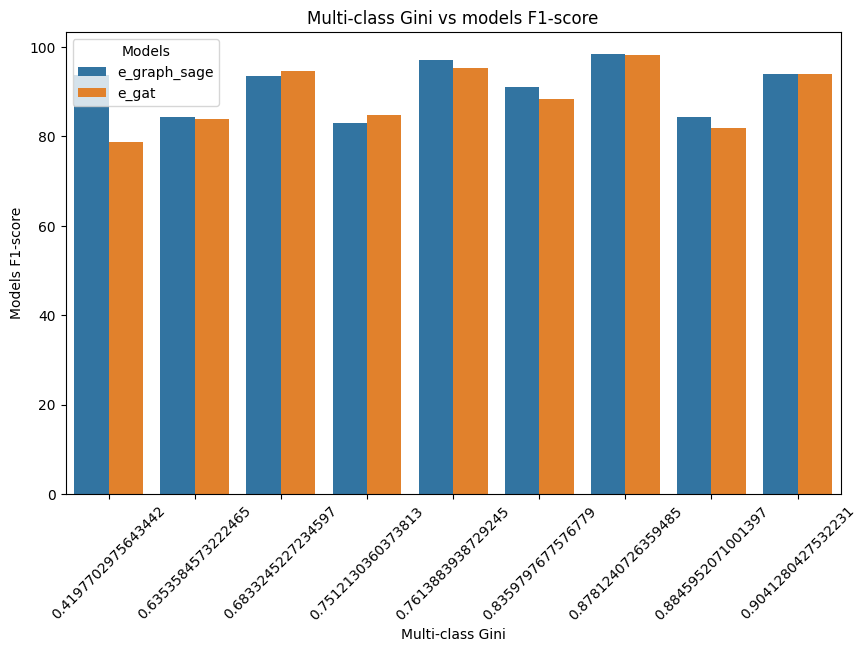

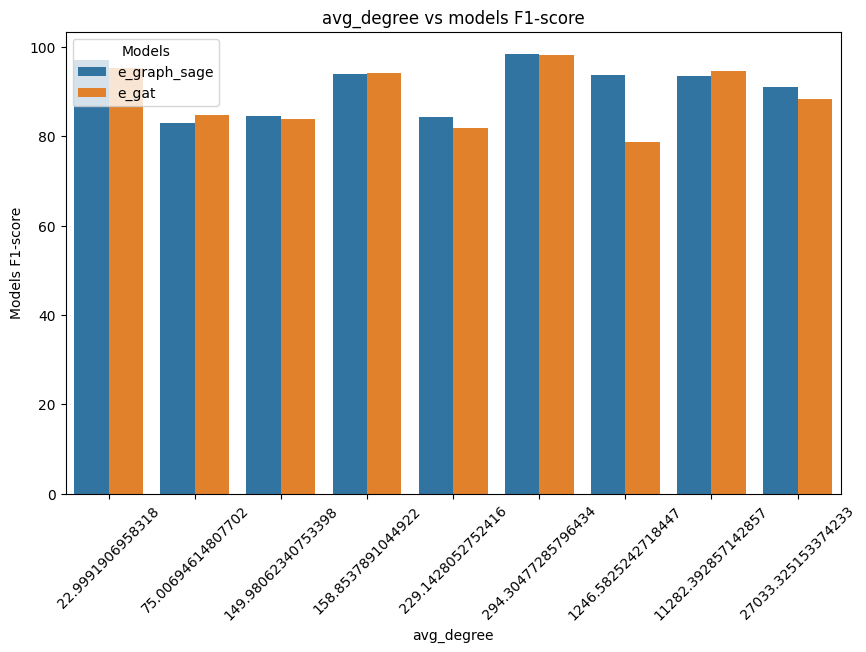

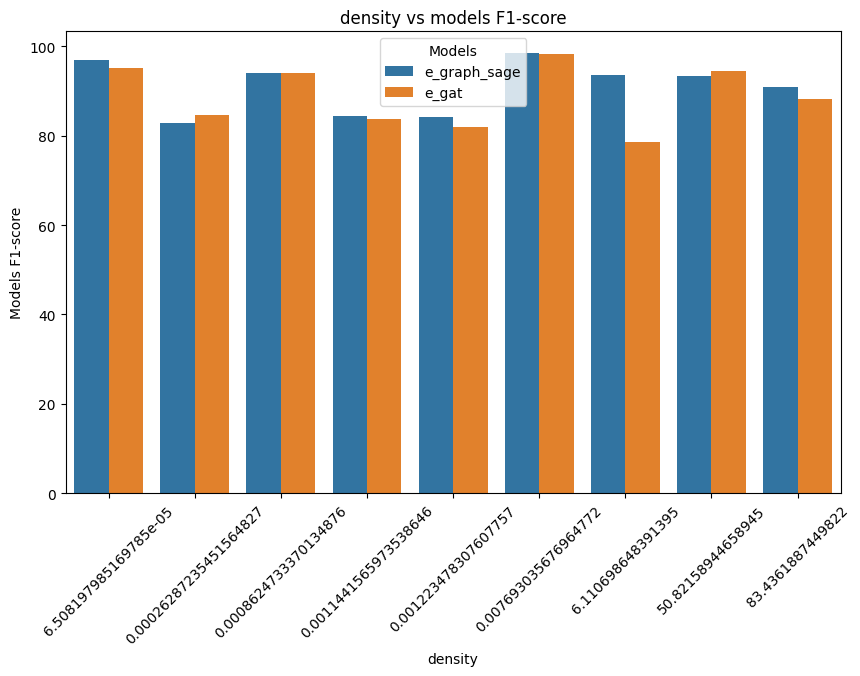

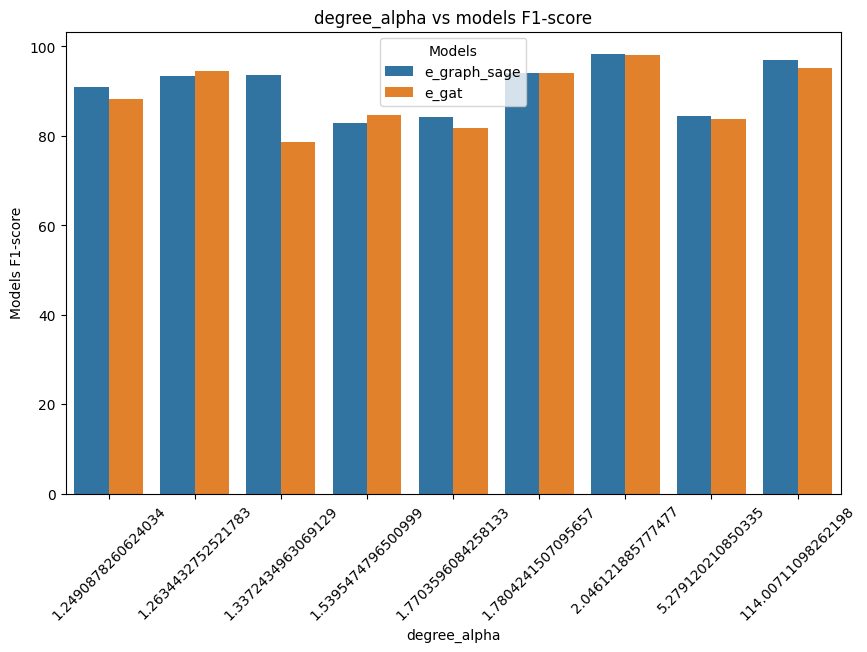

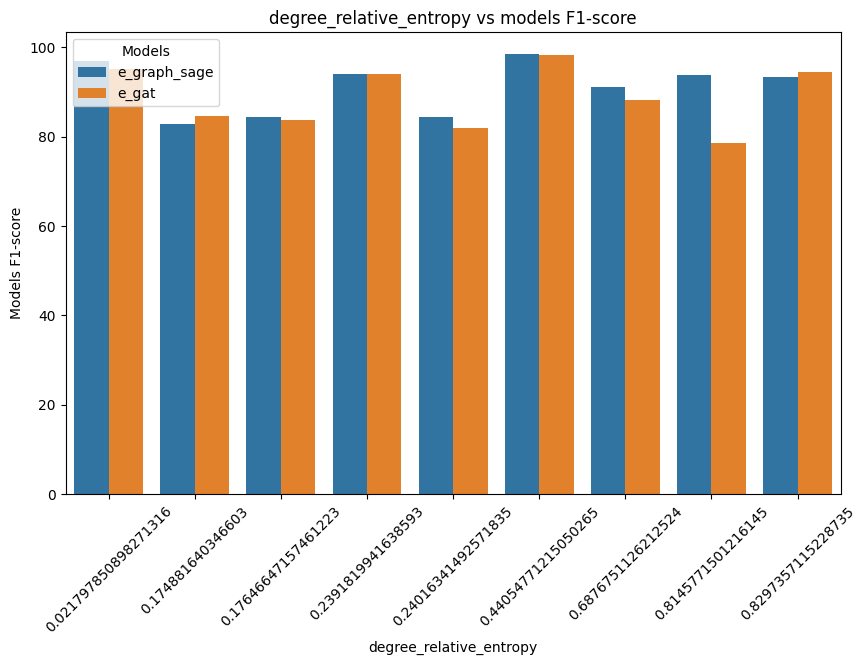

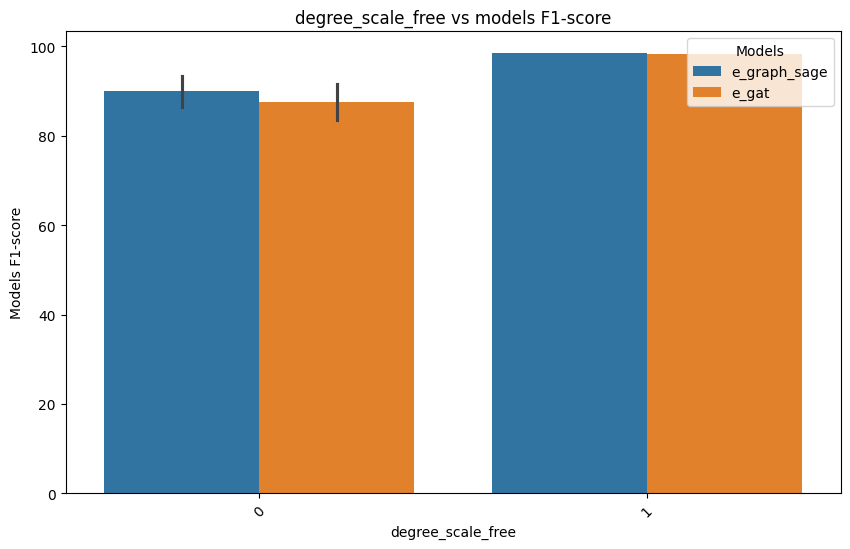

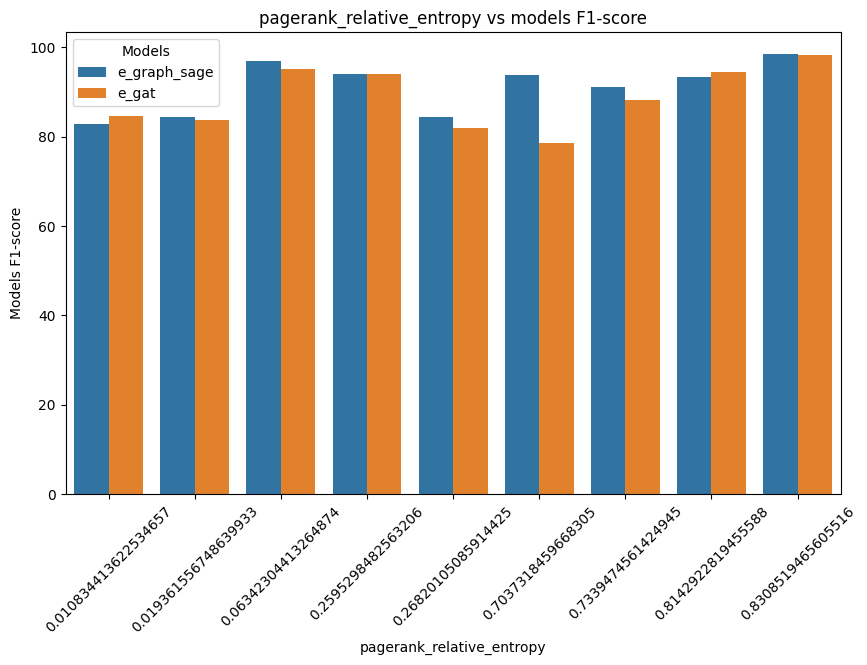

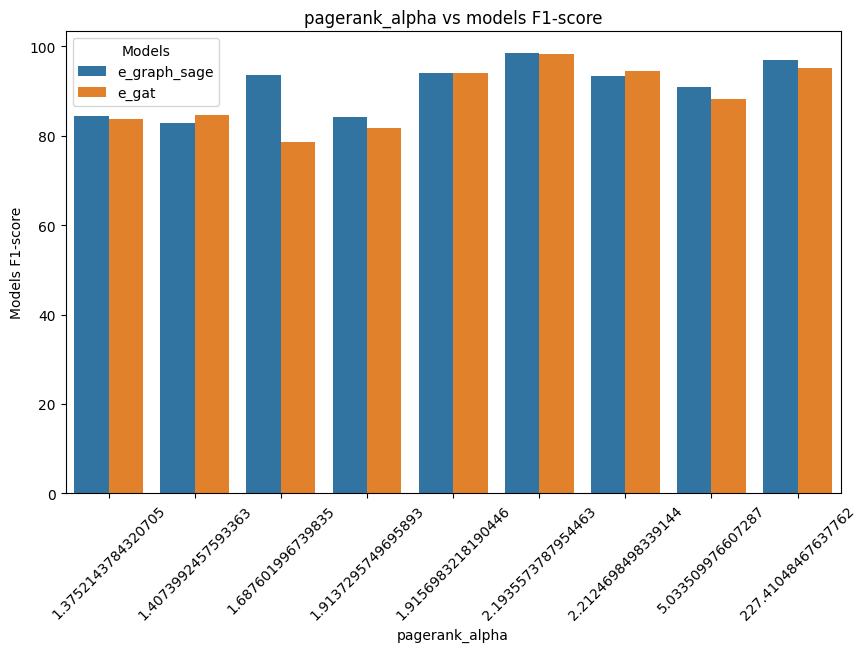

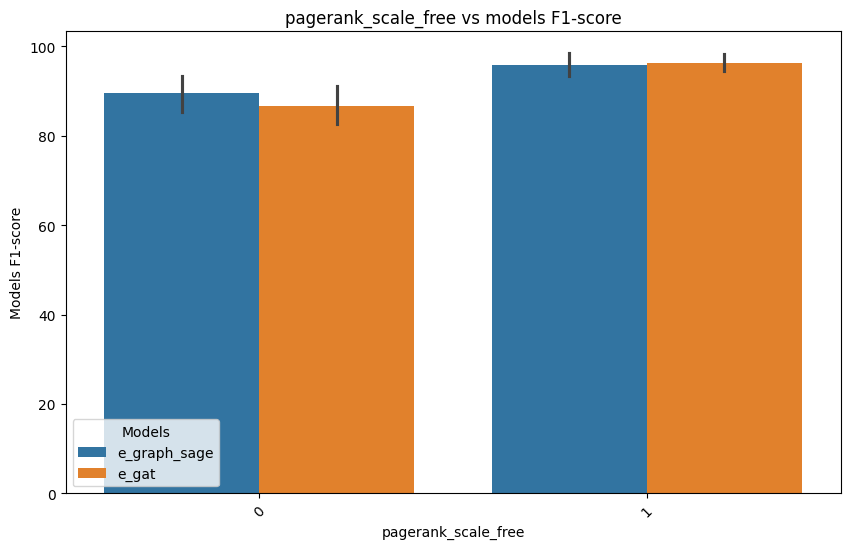

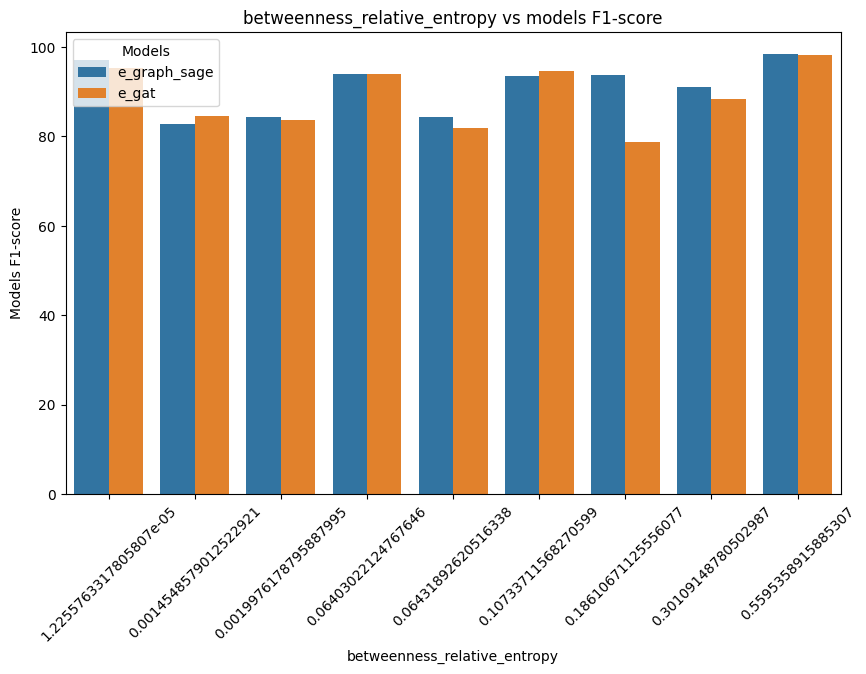

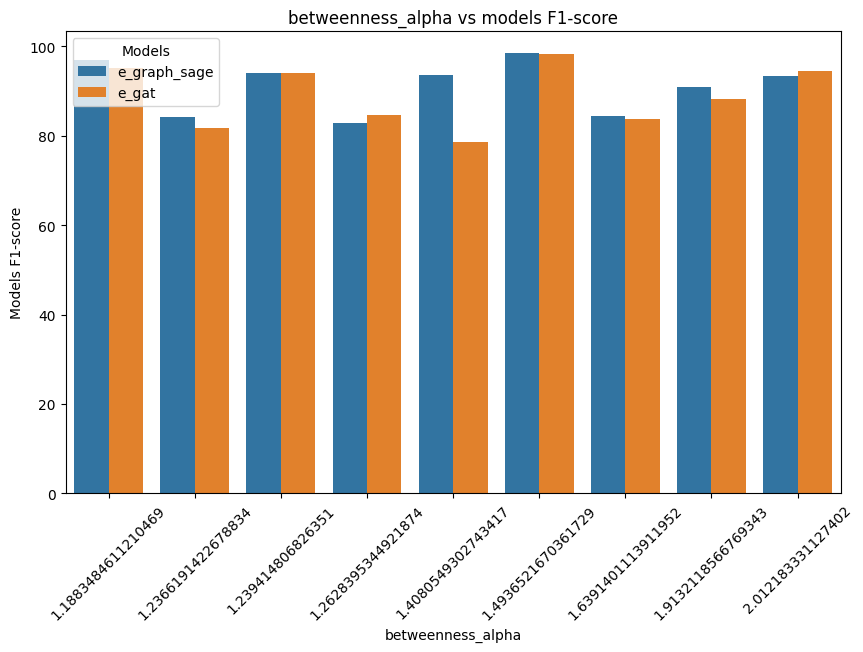

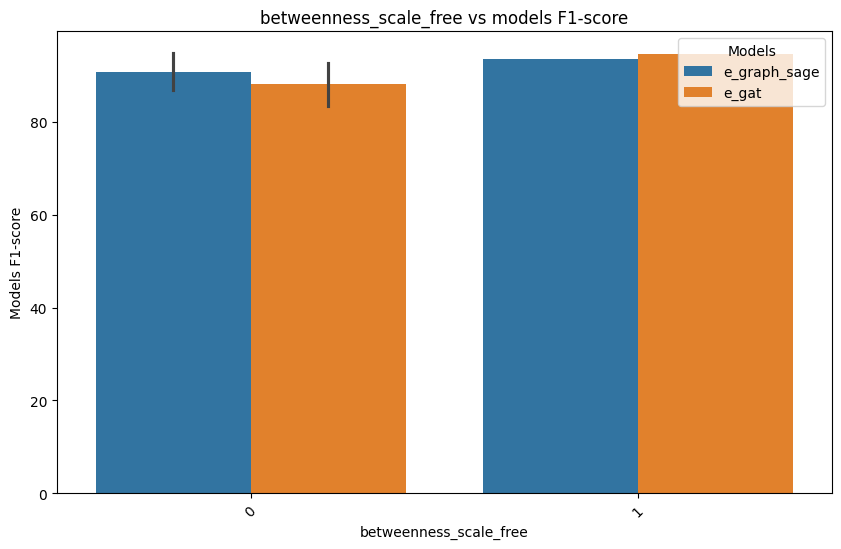

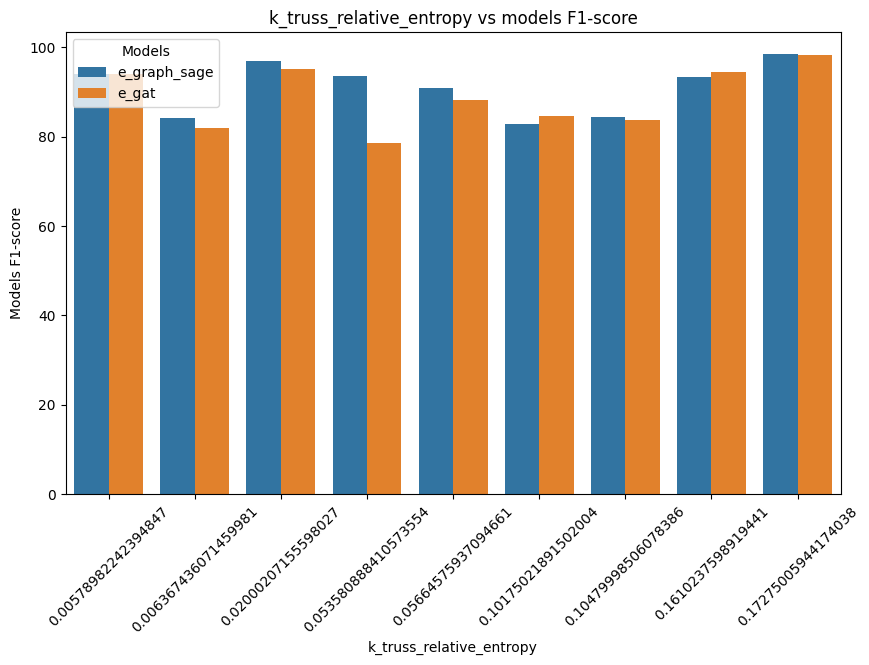

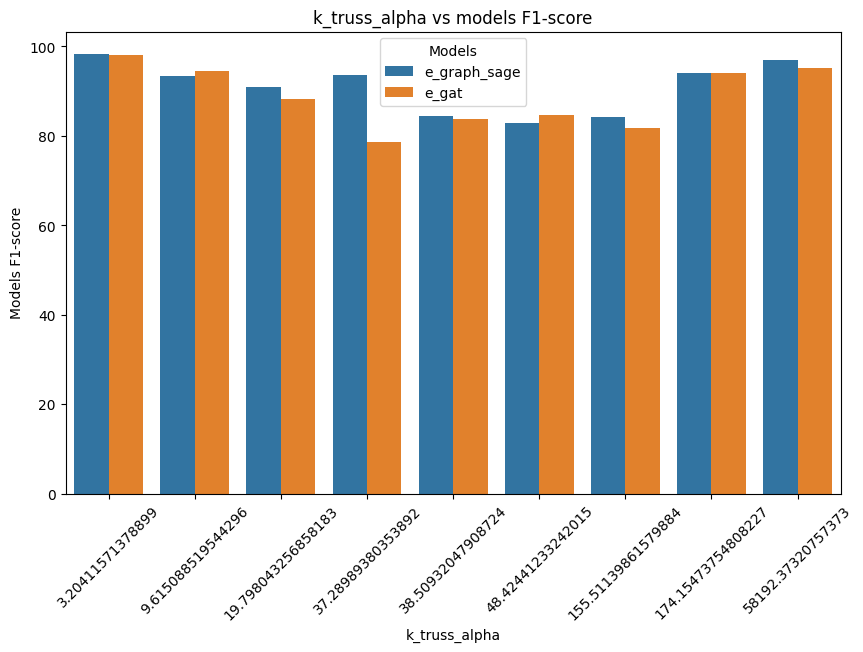

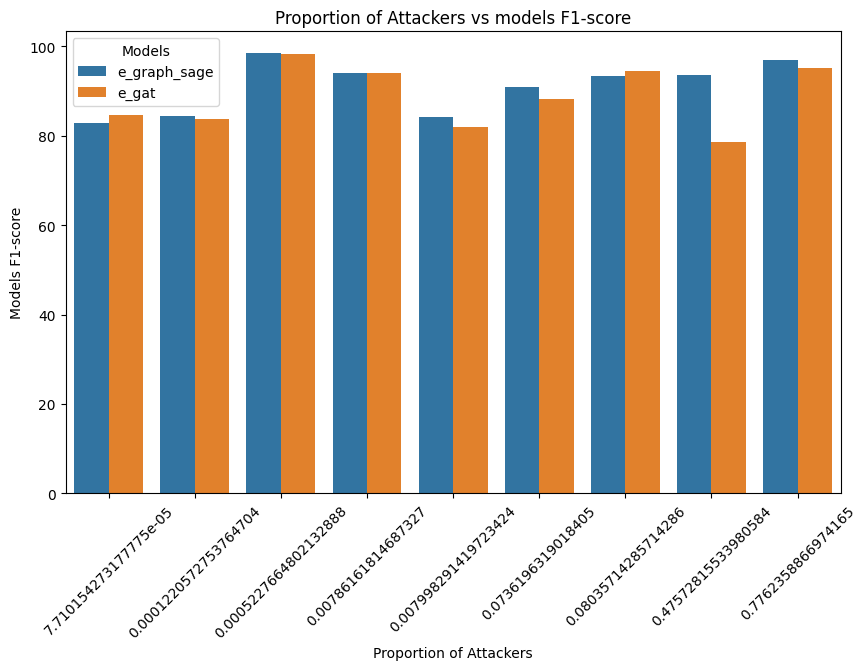

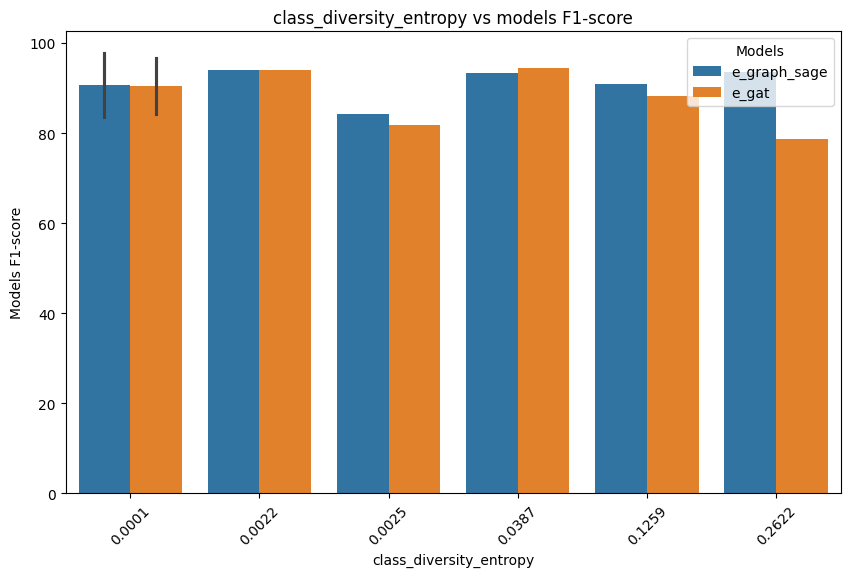

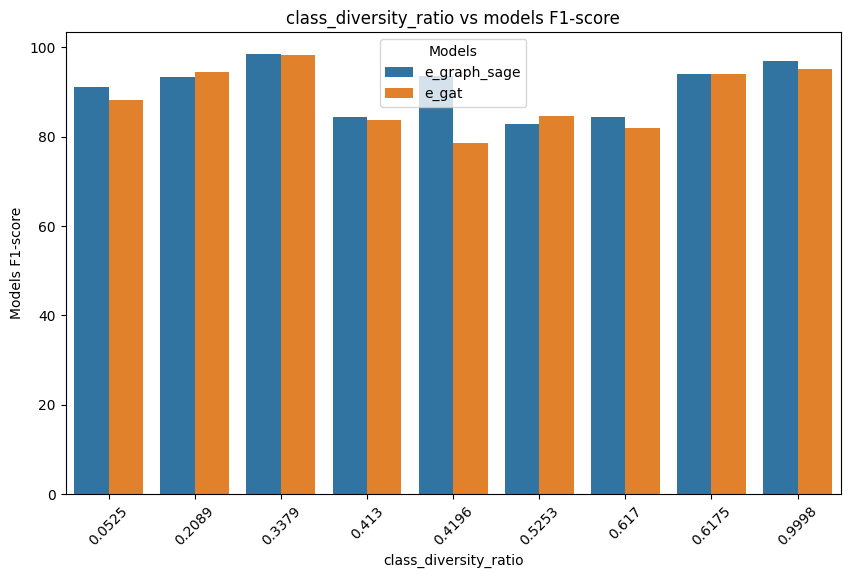

In [14]:
for feature in feature_columns:
    plt.figure(figsize=(10, 6))
    # sns.barplot(data=merged_df[["e_gcn", "e_gat", feature]].melt(id_vars=[feature], var_name='model', value_name='F1-score'),
    #             x=feature, y='F1-score', hue='model')
    sns.barplot(data=merged_df[models + [feature]].melt(id_vars=[feature], var_name='model', value_name='F1-score'),
                x=feature, y='F1-score', hue='model')

    plt.title(f'{feature} vs models F1-score')
    plt.xlabel(feature)
    plt.ylabel('Models F1-score')
    plt.legend(title="Models")
    plt.xticks(rotation=45)
    plt.show()

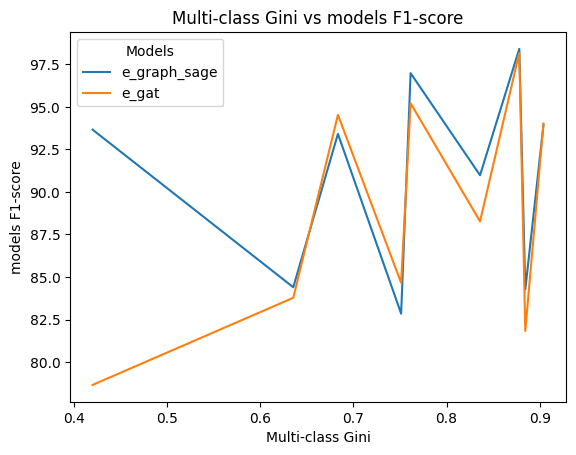

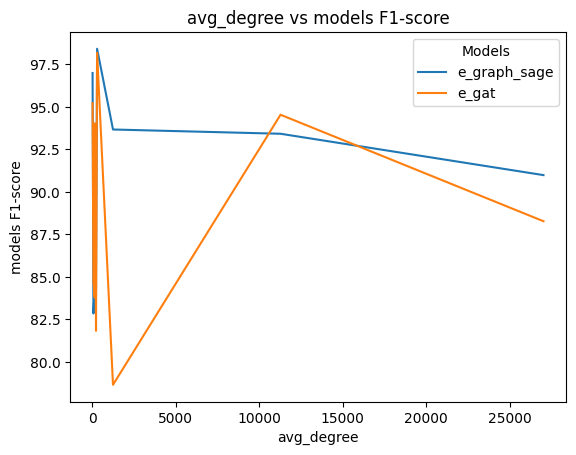

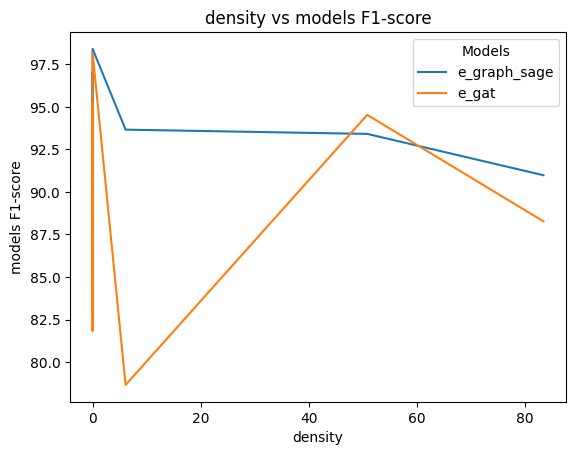

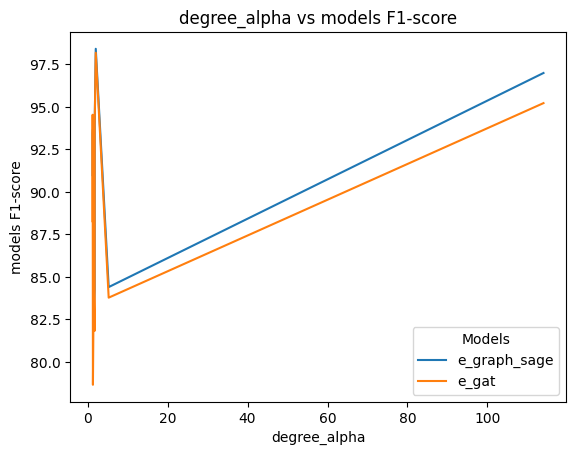

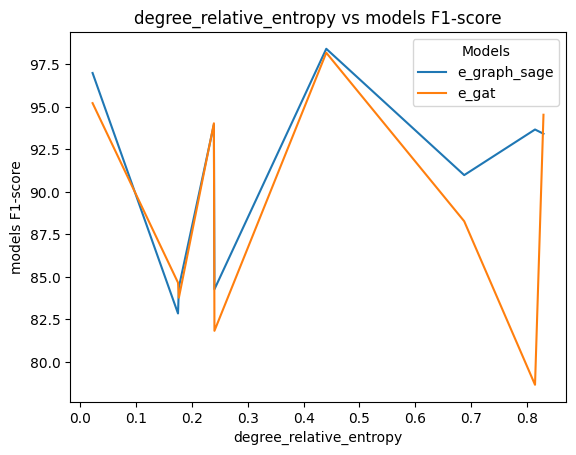

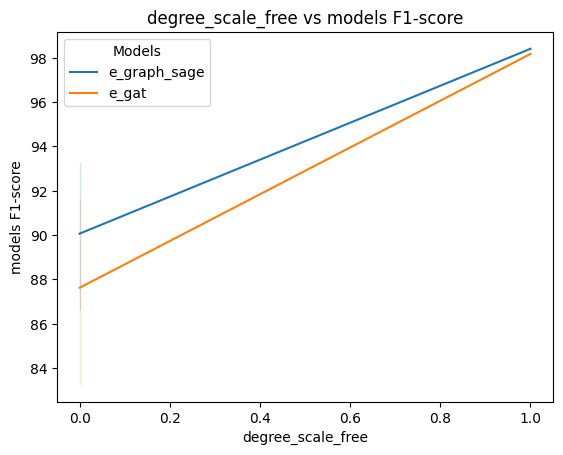

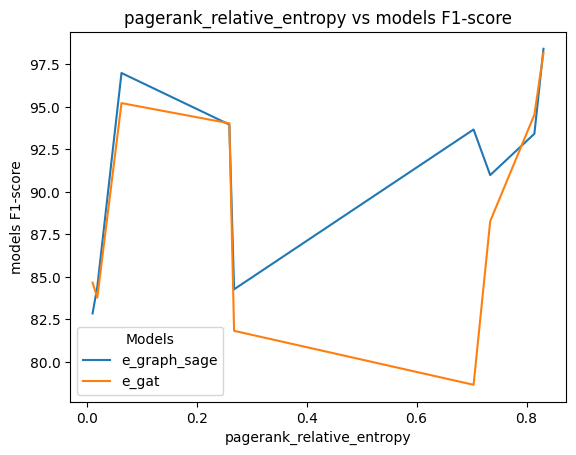

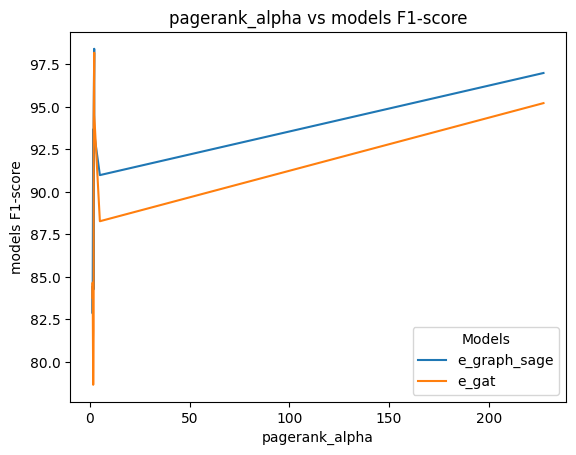

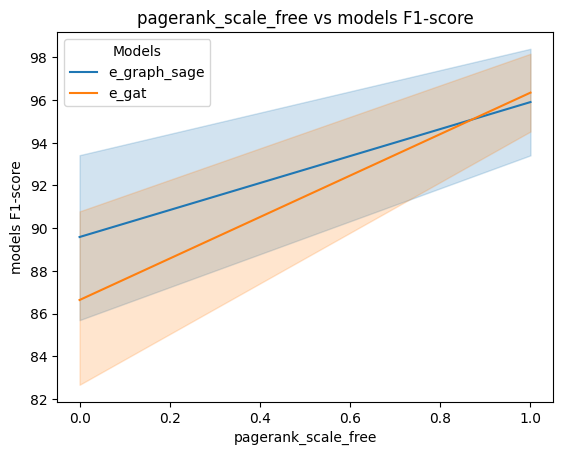

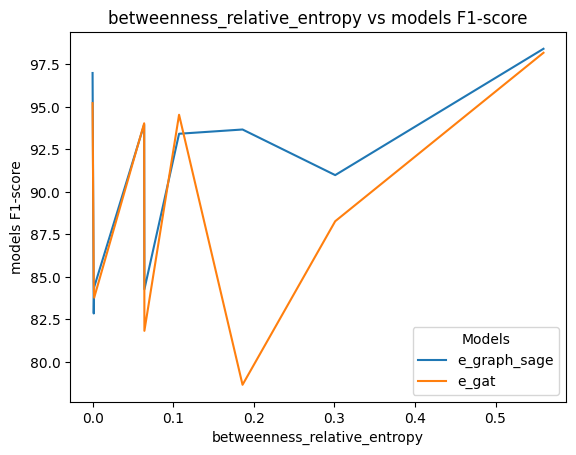

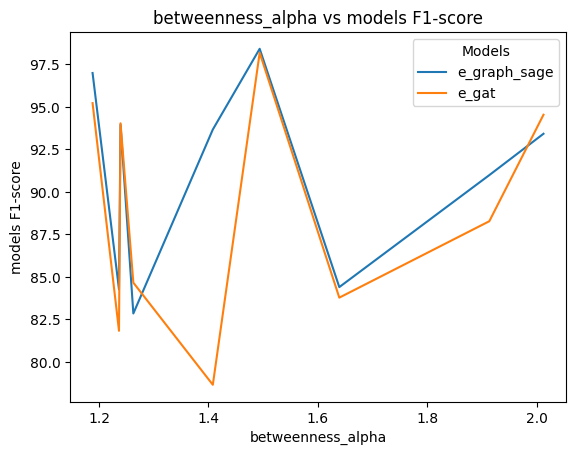

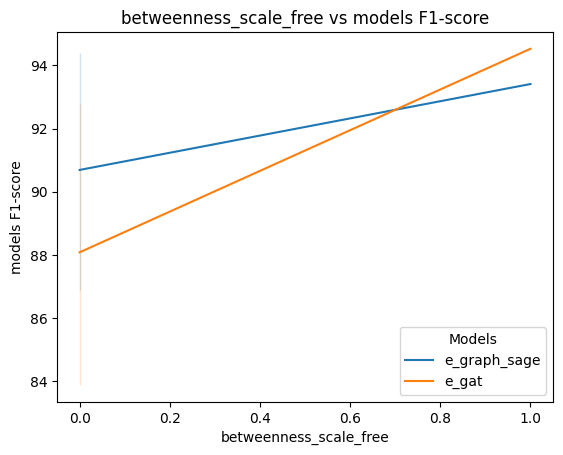

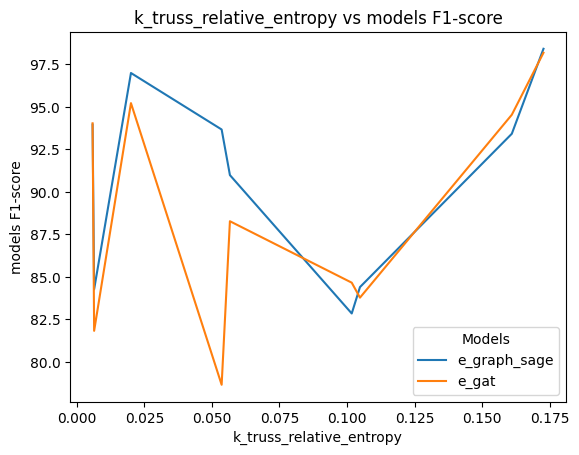

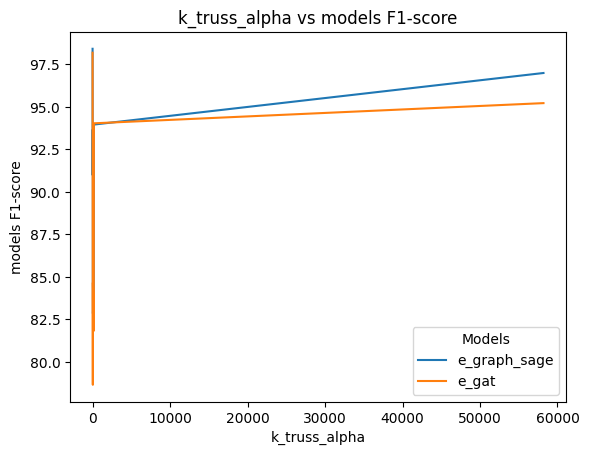

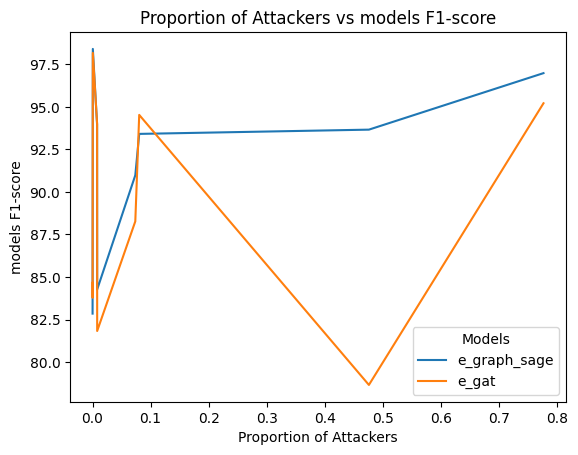

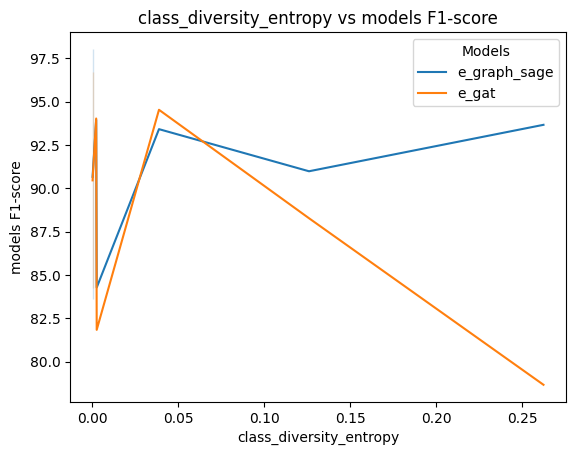

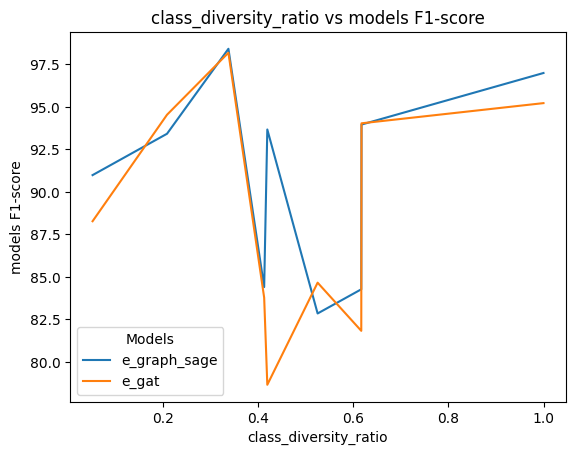

In [15]:
for feature in feature_columns:
    for m in models:
        sns.lineplot(data=merged_df, x=feature, y=m, label=m)
    plt.title(f'{feature} vs models F1-score')
    plt.xlabel(feature)
    plt.ylabel('models F1-score')
    plt.legend(title="Models")
    plt.show()


## Highest Score

In [16]:
merged_df['score_max'] = merged_df[models].max(axis=1)

In [17]:
for model in models:
    print(f"==>> model: {model}")
    better_cases = merged_df['score_max'] == merged_df[model]
    print(f"\nCases where {model} performs better:")
    print(merged_df[better_cases][['Dataset'] + models])

==>> model: e_graph_sage

Cases where e_graph_sage performs better:
                Dataset  e_graph_sage  e_gat
1          cic_ids_2017        98.403  98.17
2  cic_ton_iot_modified        84.400  83.78
3     ccd_inid_modified        93.660  78.66
4   nf_uq_nids_modified        90.980  88.27
5             edge_iiot        96.980  95.21
7            nf_uq_nids        84.270  81.83
==>> model: e_gat

Cases where e_gat performs better:
              Dataset  e_graph_sage   e_gat
0         cic_ton_iot         82.85  84.660
6  nf_cse_cic_ids2018         93.95  94.024
8              x_iiot         93.41  94.527


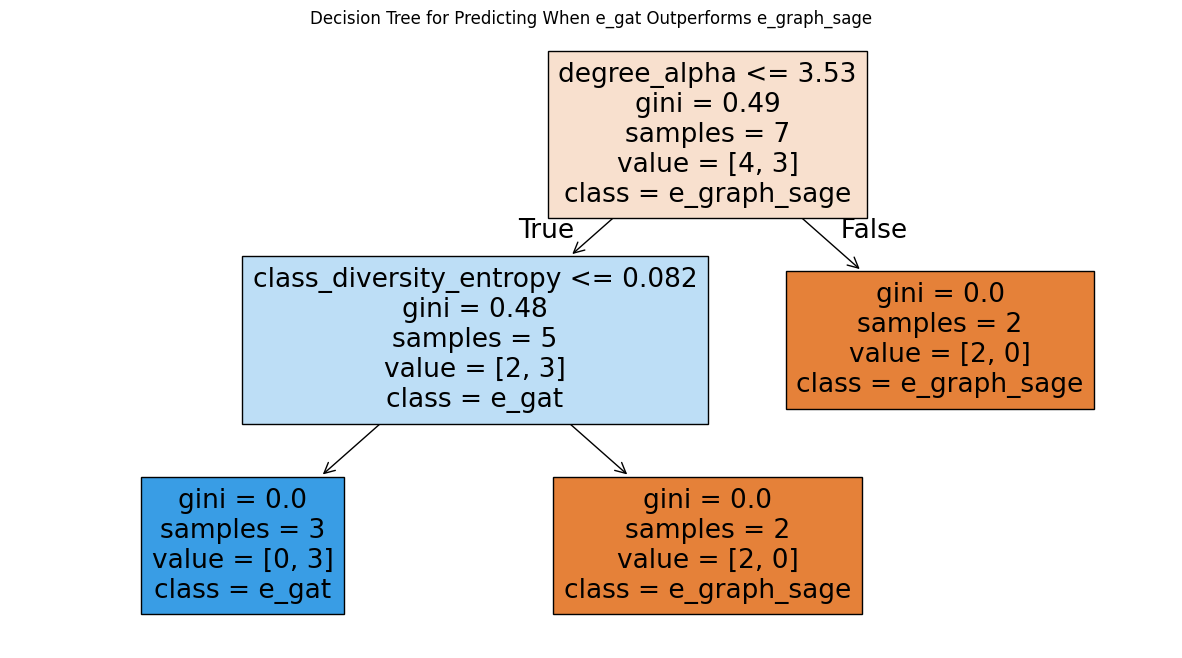

|--- degree_alpha <= 3.53
|   |--- class_diversity_entropy <= 0.08
|   |   |--- class: 1
|   |--- class_diversity_entropy >  0.08
|   |   |--- class: 0
|--- degree_alpha >  3.53
|   |--- class: 0



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split

# Create a binary target: 1 if e_gcn is better, 0 otherwise.
merged_df['target'] = (merged_df['e_gat'] > merged_df['e_graph_sage']).astype(int)

# List of feature columns to use (adjust as needed)
features = ['Multi-class Gini', 'avg_degree', 'density', 'degree_alpha',
            'degree_relative_entropy', 'degree_scale_free',
            'pagerank_relative_entropy', 'pagerank_alpha', 'pagerank_scale_free',
            'betweenness_relative_entropy', 'betweenness_alpha', 'betweenness_scale_free',
            'k_truss_relative_entropy', 'k_truss_alpha', 'Proportion of Attackers',
            'class_diversity_entropy', 'class_diversity_ratio']

X = merged_df[features]
y = merged_df['target']

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a decision tree classifier with a limited depth for interpretability
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(15, 8))
plot_tree(dtc, feature_names=features, class_names=['e_graph_sage', 'e_gat'], filled=True)
plt.title("Decision Tree for Predicting When e_gat Outperforms e_graph_sage")
plt.show()

# Optionally, print out the tree rules in text form
tree_rules = export_text(dtc, feature_names=features)
print(tree_rules)
